# Monte Carlo Simulation for Portfolio Risk Analysis

This project uses Monte Carlo simulation to evaluate portfolio downside risk.

The project includes:
- Monte Carlo price path simulation
- Correlation and covariance matrix
- Cholesky decomposition
- Portfolio simulation
- VaR and CVaR
- Scenario analysis

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

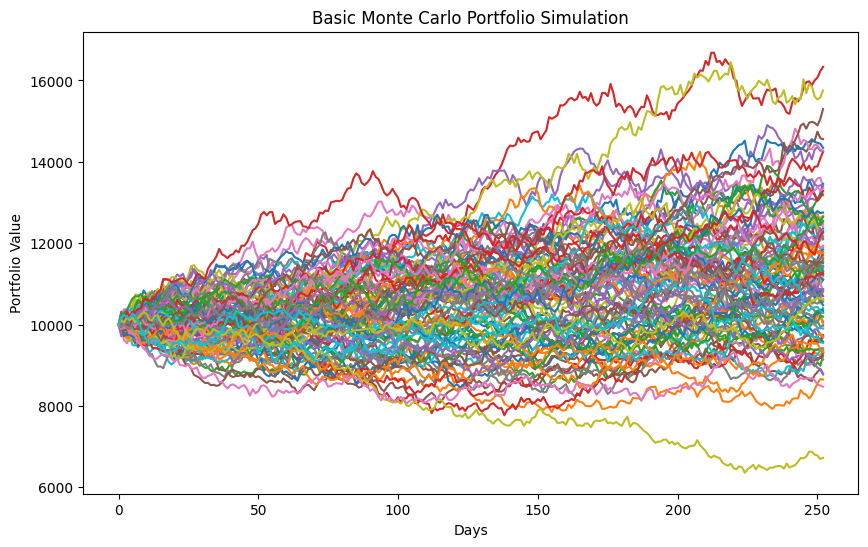

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Initial portfolio value
initial_portfolio = 10000

# Simulation settings
days = 252
simulations = 100

# Expected return and volatility
mu = 0.0005
sigma = 0.01

results = []

for sim in range(simulations):
    prices = [initial_portfolio]

    for day in range(days):
        shock = np.random.normal(mu, sigma)
        prices.append(prices[-1] * (1 + shock))

    results.append(prices)

# Plot simulations
plt.figure(figsize=(10,6))

for result in results:
    plt.plot(result)

plt.title("Basic Monte Carlo Portfolio Simulation")
plt.xlabel("Days")
plt.ylabel("Portfolio Value")

plt.show()

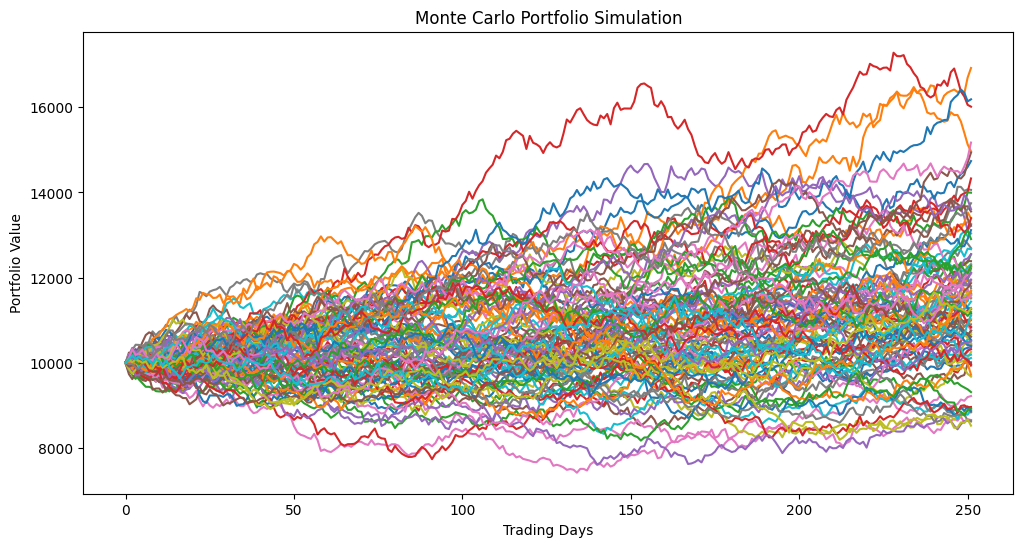

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Initial portfolio value
initial_portfolio = 10000

# Simulation settings
days = 252
simulations = 100

# Expected return and volatility
mu = 0.0005
sigma = 0.01

# Create simulation matrix
portfolio_paths = np.zeros((days, simulations))

# Run simulations
for sim in range(simulations):

    prices = [initial_portfolio]

    for day in range(days - 1):

        daily_return = np.random.normal(mu, sigma)

        new_price = prices[-1] * (1 + daily_return)

        prices.append(new_price)

    portfolio_paths[:, sim] = prices

# Plot results
plt.figure(figsize=(12,6))

plt.plot(portfolio_paths)

plt.title("Monte Carlo Portfolio Simulation")

plt.xlabel("Trading Days")

plt.ylabel("Portfolio Value")

plt.show()

## Multi-Asset Portfolio Modeling

In [12]:
initial_portfolio_value = 1_000_000
days = 252
simulations = 10000

weights = np.array([0.4, 0.4, 0.2])

mean_returns = np.array([0.0006, 0.0004, 0.0005])
volatilities = np.array([0.02, 0.015, 0.025])

In [13]:
correlation_matrix = np.array([
    [1.0, 0.6, 0.3],
    [0.6, 1.0, 0.5],
    [0.3, 0.5, 1.0]
])

correlation_df = pd.DataFrame(
    correlation_matrix,
    columns=["Asset A", "Asset B", "Asset C"],
    index=["Asset A", "Asset B", "Asset C"]
)

correlation_df

,Asset A,Asset B,Asset C
Asset A,1.0,0.6,0.3
Asset B,0.6,1.0,0.5
Asset C,0.3,0.5,1.0


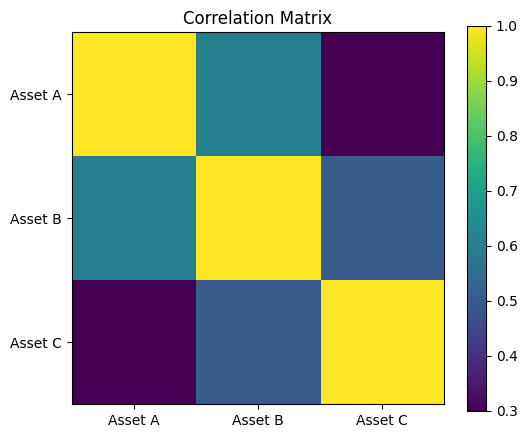

In [14]:
plt.figure(figsize=(6, 5))
plt.imshow(correlation_matrix)
plt.colorbar()
plt.xticks(range(3), ["Asset A", "Asset B", "Asset C"])
plt.yticks(range(3), ["Asset A", "Asset B", "Asset C"])
plt.title("Correlation Matrix")
plt.show()

In [15]:
D = np.diag(volatilities)
covariance_matrix = D @ correlation_matrix @ D

covariance_df = pd.DataFrame(
    covariance_matrix,
    columns=["Asset A", "Asset B", "Asset C"],
    index=["Asset A", "Asset B", "Asset C"]
)

covariance_df

,Asset A,Asset B,Asset C
Asset A,0.00040,0.000180,0.000150
Asset B,0.00018,0.000225,0.000188
Asset C,0.00015,0.000188,0.000625


In [16]:
L = np.linalg.cholesky(correlation_matrix)

L_df = pd.DataFrame(
    L,
    columns=["Factor 1", "Factor 2", "Factor 3"],
    index=["Asset A", "Asset B", "Asset C"]
)

L_df

,Factor 1,Factor 2,Factor 3
Asset A,1.0,0.0,0.000000
Asset B,0.6,0.8,0.000000
Asset C,0.3,0.4,0.866025


In [17]:
final_portfolio_values = []
all_portfolio_paths = []

for simulation in range(simulations):
    random_numbers = np.random.normal(size=(3, days))
    correlated_random_numbers = L @ random_numbers

    asset_returns = mean_returns.reshape(3, 1) + volatilities.reshape(3, 1) * correlated_random_numbers

    portfolio_daily_returns = weights @ asset_returns

    portfolio_value_path = initial_portfolio_value * np.cumprod(1 + portfolio_daily_returns)

    final_portfolio_values.append(portfolio_value_path[-1])
    all_portfolio_paths.append(portfolio_value_path)

final_portfolio_values = np.array(final_portfolio_values)
all_portfolio_paths = np.array(all_portfolio_paths)

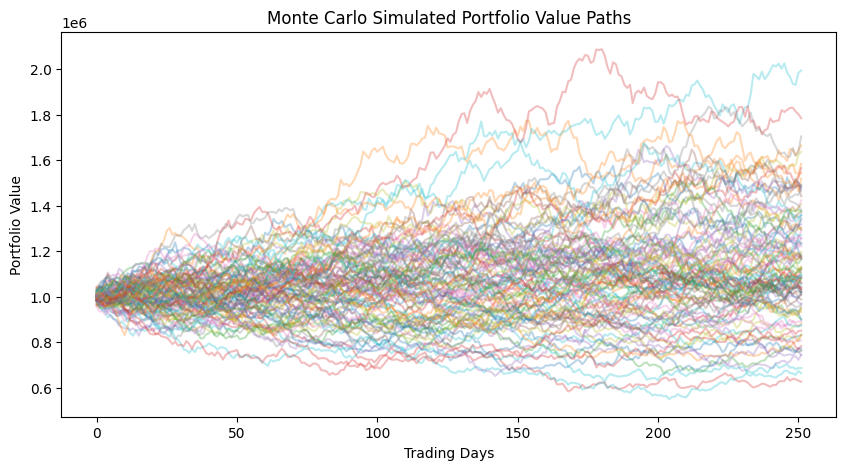

In [18]:
plt.figure(figsize=(10, 5))

for i in range(100):
    plt.plot(all_portfolio_paths[i], alpha=0.3)

plt.title("Monte Carlo Simulated Portfolio Value Paths")
plt.xlabel("Trading Days")
plt.ylabel("Portfolio Value")
plt.show()

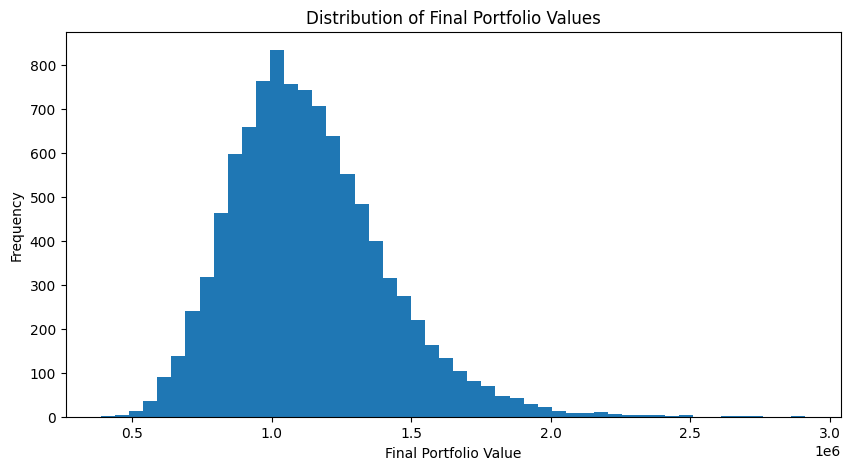

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(final_portfolio_values, bins=50)
plt.title("Distribution of Final Portfolio Values")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.show()

In [20]:
percentile_5 = np.percentile(final_portfolio_values, 5)
percentile_1 = np.percentile(final_portfolio_values, 1)

VaR_95 = initial_portfolio_value - percentile_5
VaR_99 = initial_portfolio_value - percentile_1

CVaR_95 = initial_portfolio_value - final_portfolio_values[final_portfolio_values <= percentile_5].mean()
CVaR_99 = initial_portfolio_value - final_portfolio_values[final_portfolio_values <= percentile_1].mean()

risk_results = pd.DataFrame({
    "Metric": ["Mean Final Value", "5th Percentile", "1st Percentile", "95% VaR", "99% VaR", "95% CVaR", "99% CVaR"],
    "Value": [
        final_portfolio_values.mean(),
        percentile_5,
        percentile_1,
        VaR_95,
        VaR_99,
        CVaR_95,
        CVaR_99
    ]
})

risk_results

,Metric,Value
0,Mean Final Value,1.133637e+06
1,5th Percentile,7.390165e+05
2,1st Percentile,6.215728e+05
3,95% VaR,2.609835e+05
4,99% VaR,3.784272e+05
5,95% CVaR,3.314667e+05
6,99% CVaR,4.264994e+05


In [21]:
low_correlation_matrix = np.array([
    [1.0, 0.2, 0.1],
    [0.2, 1.0, 0.2],
    [0.1, 0.2, 1.0]
])

high_correlation_matrix = np.array([
    [1.0, 0.9, 0.8],
    [0.9, 1.0, 0.85],
    [0.8, 0.85, 1.0]
])

def run_portfolio_simulation(correlation_matrix, volatilities, simulations=10000):
    L = np.linalg.cholesky(correlation_matrix)
    final_values = []

    for simulation in range(simulations):
        random_numbers = np.random.normal(size=(3, days))
        correlated_random_numbers = L @ random_numbers

        asset_returns = mean_returns.reshape(3, 1) + volatilities.reshape(3, 1) * correlated_random_numbers
        portfolio_daily_returns = weights @ asset_returns
        portfolio_value_path = initial_portfolio_value * np.cumprod(1 + portfolio_daily_returns)

        final_values.append(portfolio_value_path[-1])

    return np.array(final_values)

low_corr_values = run_portfolio_simulation(low_correlation_matrix, volatilities)
high_corr_values = run_portfolio_simulation(high_correlation_matrix, volatilities)

scenario_results = pd.DataFrame({
    "Scenario": ["Low Correlation", "High Correlation"],
    "Mean Final Value": [low_corr_values.mean(), high_corr_values.mean()],
    "95% VaR": [
        initial_portfolio_value - np.percentile(low_corr_values, 5),
        initial_portfolio_value - np.percentile(high_corr_values, 5)
    ],
    "95% CVaR": [
        initial_portfolio_value - low_corr_values[low_corr_values <= np.percentile(low_corr_values, 5)].mean(),
        initial_portfolio_value - high_corr_values[high_corr_values <= np.percentile(high_corr_values, 5)].mean()
    ]
})

scenario_results

,Scenario,Mean Final Value,95% VaR,95% CVaR
0,Low Correlation,1.133728e+06,202926.073113,266829.538685
1,High Correlation,1.134409e+06,325468.462571,402290.309383


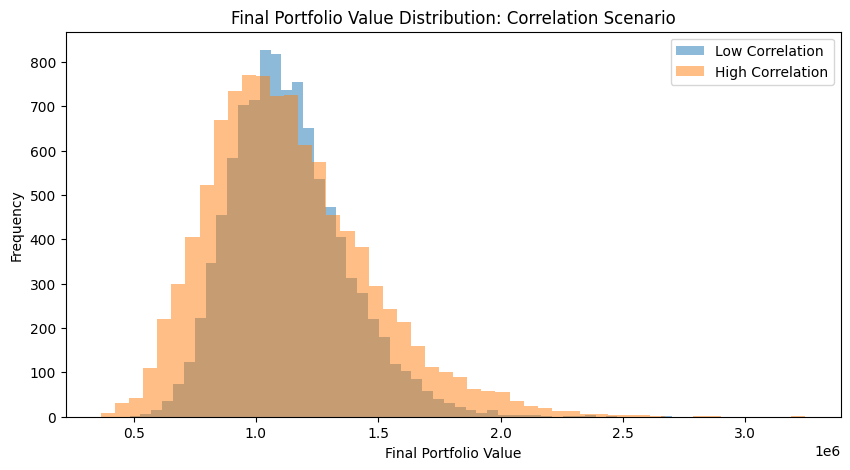

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(low_corr_values, bins=50, alpha=0.5, label="Low Correlation")
plt.hist(high_corr_values, bins=50, alpha=0.5, label="High Correlation")
plt.title("Final Portfolio Value Distribution: Correlation Scenario")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [23]:
base_volatilities = np.array([0.02, 0.015, 0.025])
high_volatilities = np.array([0.04, 0.03, 0.05])

base_vol_values = run_portfolio_simulation(correlation_matrix, base_volatilities)
high_vol_values = run_portfolio_simulation(correlation_matrix, high_volatilities)

volatility_results = pd.DataFrame({
    "Scenario": ["Base Volatility", "High Volatility"],
    "Mean Final Value": [base_vol_values.mean(), high_vol_values.mean()],
    "95% VaR": [
        initial_portfolio_value - np.percentile(base_vol_values, 5),
        initial_portfolio_value - np.percentile(high_vol_values, 5)
    ],
    "95% CVaR": [
        initial_portfolio_value - base_vol_values[base_vol_values <= np.percentile(base_vol_values, 5)].mean(),
        initial_portfolio_value - high_vol_values[high_vol_values <= np.percentile(high_vol_values, 5)].mean()
    ]
})

volatility_results

,Scenario,Mean Final Value,95% VaR,95% CVaR
0,Base Volatility,1.132237e+06,268857.244353,334434.086631
1,High Volatility,1.129083e+06,551237.910109,631998.802294


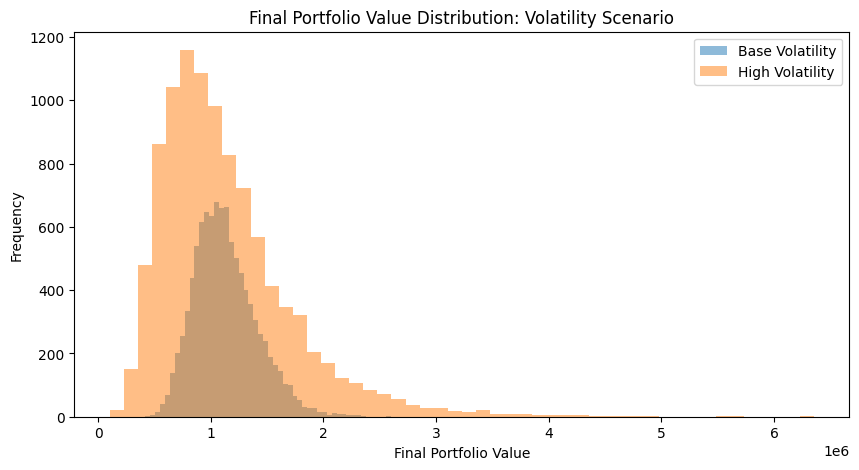

In [24]:
plt.figure(figsize=(10, 5))
plt.hist(base_vol_values, bins=50, alpha=0.5, label="Base Volatility")
plt.hist(high_vol_values, bins=50, alpha=0.5, label="High Volatility")
plt.title("Final Portfolio Value Distribution: Volatility Scenario")
plt.xlabel("Final Portfolio Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Key Takeaways

This project shows that portfolio risk cannot be evaluated only by average return.

The Monte Carlo simulation generates a full distribution of possible future portfolio values.  
VaR estimates the downside loss threshold, while CVaR measures the average loss in the worst scenarios.

The scenario analysis shows two important risk intuitions:

1. Higher correlation reduces diversification benefits.
2. Higher volatility increases downside risk and widens the final portfolio value distribution.

Overall, this project demonstrates how Python, NumPy, matrix operations, and simulation can be used for quantitative portfolio risk analysis.